## Imports

In [20]:
import sys
print(sys.executable)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

d:\Tisya\projects\AYUSH\venv\Scripts\python.exe


## Load data

In [21]:
column_names = [
    "unit",
    "cycle",
    "op_setting_1",
    "op_setting_2",
    "op_setting_3",
    "sensor_1",
    "sensor_2",
    "sensor_3",
    "sensor_4",
    "sensor_5",
    "sensor_6",
    "sensor_7",
    "sensor_8",
    "sensor_9",
    "sensor_10",
    "sensor_11",
    "sensor_12",
    "sensor_13",
    "sensor_14",
    "sensor_15",
    "sensor_16",
    "sensor_17",
    "sensor_18",
    "sensor_19",
    "sensor_20",
    "sensor_21"
]

test_raw = pd.read_csv(
    "../data/raw/FD001/test_FD001.txt",
    sep=r"\s+",
    header=None,
    names=column_names
)

print("Test shape:", test_raw.shape)
display(test_raw.head())

Test shape: (13096, 26)


,unit,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130


In [22]:
test_rul = pd.read_csv(
    "../data/raw/FD001/RUL_FD001.txt",
    sep=r"\s+",
    header=None,
    names=["RUL"]
)

print("RUL shape:", test_rul.shape)
display(test_rul.head())

print("Number of official test RUL values:", len(test_rul))

RUL shape: (100, 1)


,RUL
0,112
1,98
2,69
3,82
4,91


Number of official test RUL values: 100


In [23]:
final_features = pd.read_csv(
    "../reports/FD001/final_features.csv"
)

feature_list = final_features["feature"].tolist()

## Preparing the test features

In [24]:
X_test = test_raw[feature_list].copy()

print("X_test shape:", X_test.shape)
print("Missing values:", X_test.isna().sum().sum())


X_test shape: (13096, 18)
Missing values: 0


In [25]:
final_model = joblib.load(
    "../models/fd001_final_model.pkl"
)

print("Final model loaded successfully.")

Final model loaded successfully.


## Generating Predictions

In [26]:
test_last = (
    test_raw
    .sort_values(["unit", "cycle"])
    .groupby("unit")
    .tail(1)
    .sort_values("unit")
    .reset_index(drop=True)
)

print("Final observations:", test_last.shape)
display(
    test_last[["unit", "cycle"]].head(10)
)

X_test_last = test_last[feature_list].copy()

test_predictions = final_model.predict(X_test_last)

print("Prediction count:", len(test_predictions))

Final observations: (100, 26)


,unit,cycle
0,1,31
1,2,49
2,3,126
3,4,106
4,5,98
5,6,105
6,7,160
7,8,166
8,9,55
9,10,192


Prediction count: 100


In [27]:
actual_rul = test_rul["RUL"].to_numpy()

test_results = pd.DataFrame({
    "unit": test_last["unit"],
    "cycle": test_last["cycle"],
    "actual_rul": actual_rul,
    "predicted_rul": test_predictions
})

test_results["error"] = (
    test_results["actual_rul"]
    - test_results["predicted_rul"]
)

test_results["absolute_error"] = (
    test_results["error"].abs()
)

display(test_results.head(10))


,unit,cycle,actual_rul,predicted_rul,error,absolute_error
0,1,31,112,176.189087,-64.189087,64.189087
1,2,49,98,151.396057,-53.396057,53.396057
2,3,126,69,53.929405,15.070595,15.070595
3,4,106,82,82.878761,-0.878761,0.878761
4,5,98,91,105.071907,-14.071907,14.071907
5,6,105,93,90.133583,2.866417,2.866417
6,7,160,91,104.181549,-13.181549,13.181549
7,8,166,95,70.679382,24.320618,24.320618
8,9,55,111,137.881424,-26.881424,26.881424
9,10,192,96,116.743385,-20.743385,20.743385


## The official test metrics

In [28]:
test_mae = mean_absolute_error(
    test_results["actual_rul"],
    test_results["predicted_rul"]
)

test_rmse = np.sqrt(
    mean_squared_error(
        test_results["actual_rul"],
        test_results["predicted_rul"]
    )
)

test_r2 = r2_score(
    test_results["actual_rul"],
    test_results["predicted_rul"]
)

print("Official FD001 Test Results")
print("MAE :", round(test_mae, 3))
print("RMSE:", round(test_rmse, 3))
print("R²  :", round(test_r2, 3))

Official FD001 Test Results
MAE : 19.627
RMSE: 26.767
R²  : 0.585


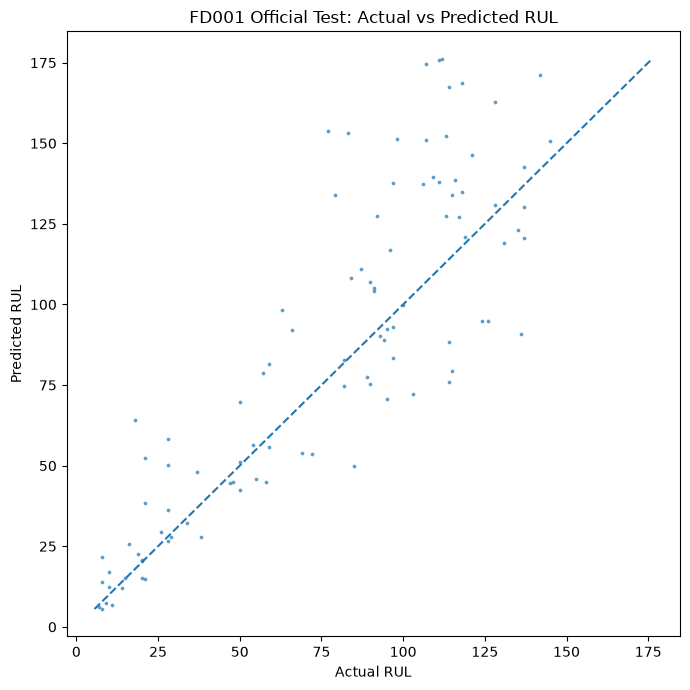

In [34]:
plt.figure(figsize=(7, 7))

plt.scatter(
    test_results["actual_rul"],
    test_results["predicted_rul"],
    alpha=0.6,
    s=3
)

min_value = min(
    test_results["actual_rul"].min(),
    test_results["predicted_rul"].min()
)

max_value = max(
    test_results["actual_rul"].max(),
    test_results["predicted_rul"].max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("FD001 Official Test: Actual vs Predicted RUL")

plt.tight_layout()

plt.savefig(
    "../reports/FD001/figures/final/FD001_Test_Actual_vs_Predicted_RUL.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


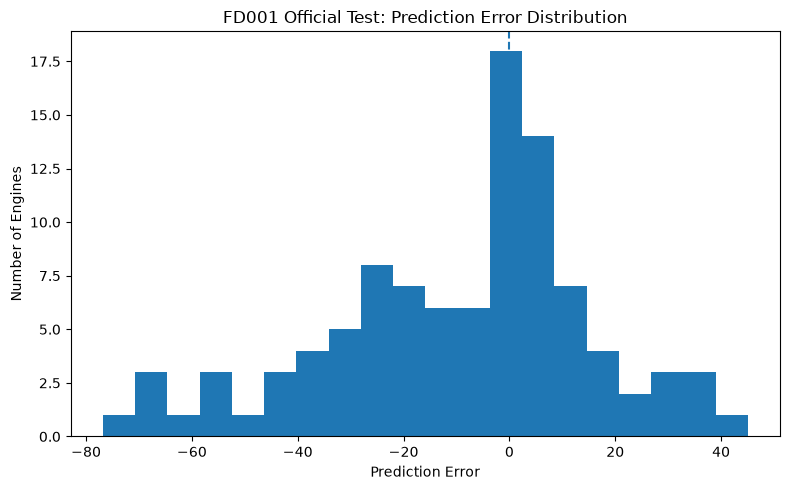

In [35]:
plt.figure(figsize=(8, 5))

plt.hist(
    test_results["error"],
    bins=20
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Prediction Error")
plt.ylabel("Number of Engines")
plt.title("FD001 Official Test: Prediction Error Distribution")

plt.tight_layout()

plt.savefig(
    "../reports/FD001/figures/final/FD001_Test_Error_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [29]:
test_results.to_csv(
    "../reports/FD001/fd001_test_predictions.csv",
    index=False
)

print(
    "Saved:",
    "../reports/FD001/fd001_test_predictions.csv"
)


Saved: ../reports/FD001/fd001_test_predictions.csv


In [30]:
test_metrics = pd.DataFrame({
    "model": ["Final XGBoost"],
    "MAE": [test_mae],
    "RMSE": [test_rmse],
    "R2": [test_r2]
})

display(test_metrics)

test_metrics.to_csv(
    "../reports/FD001/fd001_test_results.csv",
    index=False
)

print(
    "Saved:",
    "../reports/FD001/fd001_test_results.csv"
)


,model,MAE,RMSE,R2
0,Final XGBoost,19.627178,26.767195,0.585097


Saved: ../reports/FD001/fd001_test_results.csv
